# Quantum vs. Classical Kernel Methods - A 3-Way Comparison

**Local VS Code edition.** Runs inside a project-local virtual environment on your own machine.

**Dataset:** switchable between **Breast Cancer Wisconsin** and **Iris** (both ship with
scikit-learn - no network fetch, no `ucimlrepo`).

**Three kernels compared on one fixed train/test split:**
 
| # | Method | Where it runs |
|---|--------|----------------|
| 1 | Classical **RBF** kernel SVM | Local CPU (sklearn) |
| 2 | Classical **Polynomial** kernel SVM | Local CPU (sklearn) |
| 3 | **Quantum kernel - local simulation** (ZZ feature map + FidelityQuantumKernel) | Local Aer simulator (CPU, GPU if available) |

**Notebook structure:**
 
- Sections 0-4 configure the environment, prepare the data, evaluate all three kernels, and visualize their matrices.
- Section 5 summarizes the results and reports whether the quantum kernel shows a measurable advantage.

---

### Before you start - venv setup (do this in a terminal, once)

See `README.md` for the same steps. From the project folder:

**macOS / Linux**
```bash
python3 -m venv .venv
source .venv/bin/activate
pip install --upgrade pip
pip install -r requirements.txt
```

**Windows (PowerShell)**
```powershell
py -m venv .venv
.\.venv\Scripts\Activate.ps1
python -m pip install --upgrade pip
pip install -r requirements.txt
```

Then in VS Code: open this notebook -> click the **kernel picker** (top right) -> **Select Another Kernel...
-> Python Environments...** -> pick the one whose path contains `.venv`. Section 0 verifies you picked
the right one.

## 0. Environment Setup 🟢 *(safe to re-run anytime)*

There are **no `%pip install` cells in this notebook** — that is the main structural difference
from the Colab original. Dependencies are installed once into `.venv` from `requirements.txt`
before the notebook is opened. Installing into a running kernel is what forces the
"restart the runtime and re-run from the top" dance that the Colab version warned about;
a pre-built venv avoids it entirely.

The cell below is a **verification** cell, not an install cell. It confirms the kernel you
selected in VS Code is actually the project venv.

In [1]:
import subprocess
import sys
import os

venv_path = r"C:\Users\emkap\OneDrive\Documents\Projects\QC_CCA-1\.venv"

# Confirm the current kernel is indeed pointing at this venv.
print("Current Python executable:", sys.executable)
if venv_path not in sys.executable:
    print(f"*** WARNING: current kernel does not appear to be under '{venv_path}'. ***")
    print("Select the correct interpreter via the VS Code kernel picker before proceeding.")
else:
    print(f"Kernel confirmed to be running from: {venv_path}")

requirements_path = os.path.join(
    r"C:\Users\emkap\OneDrive\Documents\Projects\QC_CCA-1", "requirements.txt"
)

if not os.path.exists(requirements_path):
    print(f"requirements.txt not found at '{requirements_path}'. Skipping install.")
else:
    print(f"Installing dependencies from '{requirements_path}' using {sys.executable} ...")
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", "--upgrade", "-r", requirements_path],
        capture_output=True, text=True,
    )
    print(result.stdout)
    if result.returncode != 0:
        print("*** Errors during installation: ***")
        print(result.stderr)
    else:
        print("All requirements installed successfully.")

Current Python executable: c:\Users\emkap\OneDrive\Documents\Projects\QC_CCA-1\.venv\Scripts\python.exe
*** WARNING: current kernel does not appear to be under 'C:\Users\emkap\OneDrive\Documents\Projects\QC_CCA-1\.venv'. ***
Select the correct interpreter via the VS Code kernel picker before proceeding.
Installing dependencies from 'C:\Users\emkap\OneDrive\Documents\Projects\QC_CCA-1\requirements.txt' using c:\Users\emkap\OneDrive\Documents\Projects\QC_CCA-1\.venv\Scripts\python.exe ...

All requirements installed successfully.


In [2]:
import sys, os

in_venv = sys.prefix != sys.base_prefix
venv_name = os.path.basename(sys.prefix)

print("Python executable :", sys.executable)
print("Python version    :", sys.version.split()[0])
print("Inside a venv     :", in_venv, f"({venv_name})" if in_venv else "")

if not in_venv:
    print(
        "\n*** WARNING: this kernel is NOT a virtual environment. ***\n"
        "In VS Code: kernel picker (top-right) -> 'Select Another Kernel...' ->\n"
        "'Python Environments...' -> choose the interpreter under .venv, then re-run this cell.\n"
        "If .venv does not appear, create it first (see README.md) and reload the VS Code window."
    )
else:
    print("\nGood - running inside the project virtual environment.")

Python executable : c:\Users\emkap\OneDrive\Documents\Projects\QC_CCA-1\.venv\Scripts\python.exe
Python version    : 3.12.10
Inside a venv     : True (.venv)

Good - running inside the project virtual environment.


In [3]:
import warnings
warnings.filterwarnings("ignore")

import time
import getpass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer, load_iris
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics.pairwise import rbf_kernel, polynomial_kernel

import qiskit
import qiskit_aer
import qiskit_machine_learning
import sklearn

print("qiskit                  :", qiskit.__version__)
print("qiskit-aer              :", qiskit_aer.__version__)
print("qiskit-machine-learning :", qiskit_machine_learning.__version__)
print("scikit-learn            :", sklearn.__version__)
print("numpy                   :", np.__version__)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Render plots inline in the VS Code notebook output.
%matplotlib inline

qiskit                  : 2.5.2
qiskit-aer              : 0.17.2
qiskit-machine-learning : 0.9.1
scikit-learn            : 1.9.1
numpy                   : 2.5.3


### 0.1 Local Aer simulator device

The Colab original installed `qiskit-aer-gpu-cu11` and assumed a T4. Most local machines have
no CUDA GPU, so `requirements.txt` installs the **CPU** build of Aer, and the helper below tries
`GPU` first and falls back to `CPU`. If you do have an NVIDIA GPU and want to use it, install
`qiskit-aer-gpu` instead of `qiskit-aer` (see `README.md`) — this cell will then pick the GPU up
automatically with no code change.

In [4]:
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit
from qiskit_aer.primitives import SamplerV2 as AerSamplerV2


def make_aer_sampler(shots=1024):
    """Build a qiskit-machine-learning-compatible Sampler backed by AerSimulator,
    preferring GPU and falling back to CPU."""
    for device in ("GPU", "CPU"):
        try:
            # The sampler that gets returned and actually used later must itself be
            # configured for this device: AerSamplerV2's own backend_options is what
            # controls which device it runs on.
            backend_options = {"method": "automatic", "device": device}
            sampler = AerSamplerV2(default_shots=shots, options={"backend_options": backend_options})
            # Smoke-test with a trivial circuit, run through the sampler itself.
            qc = QuantumCircuit(1, 1)
            qc.h(0)
            qc.measure(0, 0)
            _ = sampler.run([qc], shots=16).result()
            print(f"AerSimulator device='{device}' is working - using it for local quantum kernels.")
            return sampler, device
        except Exception as e:
            print(f"AerSimulator device='{device}' unavailable ({type(e).__name__}); trying next option...")
    raise RuntimeError("No working AerSimulator backend (GPU or CPU) could be initialized.")


LOCAL_SAMPLER, LOCAL_DEVICE = make_aer_sampler()
print("Local simulation device in use:", LOCAL_DEVICE)

AerSimulator device='GPU' unavailable (RuntimeError); trying next option...
AerSimulator device='CPU' is working - using it for local quantum kernels.
Local simulation device in use: CPU


## 1. Data: Breast Cancer *or* Iris (scikit-learn built-ins) 🟢

Set `DATASET` below. Both datasets ship inside scikit-learn, so there is no download and no
`ucimlrepo` dependency — this notebook runs fully offline.

| `DATASET` | Source | Samples | Features | Classes used |
|---|---|---|---|---|
| `"breast_cancer"` | Breast Cancer Wisconsin (Diagnostic) | 569 | 30 | malignant vs. benign (already binary) |
| `"iris"` | Fisher's Iris | 150 (100 used) | 4 | versicolor vs. virginica (binary subset) |

**Two dataset-specific decisions, both deliberate:**

1. **Breast cancer needs dimensionality reduction.** One qubit is used per feature, so 30 raw
   features would mean a 30-qubit circuit — far beyond what simulates quickly, and beyond the
   qubit count this comparison is meant to exercise. We standardize and then apply **PCA down to
   `N_QUBITS` (default 4) components**, which also happens to match the original notebook's
   4-feature / 4-qubit geometry. PCA is fit on the **training split only**, then applied to test —
   fitting it on the full dataset would leak test information into the transform.

2. **Iris is 3-class; kernel-target alignment is defined for binary labels.** We keep the
   **versicolor vs. virginica** pair, which is the genuinely overlapping pair. (Setosa is linearly
   separable from the other two, so any setosa-containing pair scores ~100% for every kernel and
   the comparison becomes uninformative.) Iris already has 4 features, so no PCA is applied.

As in the original, we then take a **documented, class-balanced sub-sample** before splitting.
This is a runtime decision, not an accuracy hack: quantum kernel evaluation cost for a Gram matrix
scales as *O(N²)* state-fidelity circuits. The classical kernels are evaluated on the exact same
sub-sample and exact same split, so the comparison stays apples-to-apples.

In [5]:
# ============ MAIN CONFIGURATION ============
DATASET = "iris"   # "breast_cancer" or "iris"
N_QUBITS = 4                # PCA target dimensionality == number of qubits in the feature map
IRIS_CLASSES = (1, 2)       # versicolor vs virginica (see markdown above)
# ============================================

if DATASET == "breast_cancer":
    data = load_breast_cancer()
    X_full = data.data
    y_full = data.target
    feature_names = list(data.feature_names)
    class_names = [str(n) for n in data.target_names]
    DATASET_LABEL = "Breast Cancer Wisconsin (sklearn)"
elif DATASET == "iris":
    data = load_iris()
    keep = np.isin(data.target, IRIS_CLASSES)
    X_full = data.data[keep]
    # Re-map the two kept classes to {0, 1}; the higher class id becomes 1.
    y_full = (data.target[keep] == max(IRIS_CLASSES)).astype(int)
    feature_names = list(data.feature_names)
    class_names = [str(data.target_names[c]) for c in IRIS_CLASSES]
    DATASET_LABEL = f"Iris ({class_names[0]} vs {class_names[1]}, sklearn)"
else:
    raise ValueError(f"DATASET must be 'breast_cancer' or 'iris', got {DATASET!r}")

print(f"Dataset: {DATASET_LABEL}")
print(f"Shape: {X_full.shape}  ({len(feature_names)} features)")
print(f"Classes: 0 = {class_names[0]}, 1 = {class_names[1]}")
print("Class balance (full dataset):")
print(pd.Series(y_full).value_counts().sort_index().rename("count").to_string())

Dataset: Iris (versicolor vs virginica, sklearn)
Shape: (100, 4)  (4 features)
Classes: 0 = versicolor, 1 = virginica
Class balance (full dataset):
0    50
1    50


In [6]:
# --- Documented sub-sampling decision ---
# Rough local-CPU cost of the Section 4 quantum kernel (N*(N-1)/2 fidelity circuits):
#   SUBSAMPLE_SIZE=50  -> ~35 train pts ->   ~600 circuits ->  seconds
#   SUBSAMPLE_SIZE=100 -> ~70 train pts ->  ~2400 circuits ->  ~20-60 s
#   SUBSAMPLE_SIZE=200 -> ~140 train pts -> ~9700 circuits ->  several minutes
SUBSAMPLE_SIZE = 200
TEST_FRACTION = 0.30

if SUBSAMPLE_SIZE < len(X_full):
    X_sub, _, y_sub, _ = train_test_split(
        X_full, y_full,
        train_size=SUBSAMPLE_SIZE,
        stratify=y_full,
        random_state=RANDOM_STATE,
    )
else:
    X_sub, y_sub = X_full, y_full

print(f"Using a class-balanced sub-sample of {len(X_sub)} / {len(X_full)} points.")
print(pd.Series(y_sub).value_counts(normalize=True).sort_index().rename("class fraction").to_string())

# ONE fixed train/test split, reused identically by all four classifiers below.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_sub, y_sub,
    test_size=TEST_FRACTION,
    stratify=y_sub,
    random_state=RANDOM_STATE,
)

Using a class-balanced sub-sample of 100 / 100 points.
0    0.5
1    0.5


In [7]:
# --- Preprocessing pipeline: (standardize + PCA if needed) -> scale to [0, pi] ---
# Every transform is FIT ON TRAIN ONLY and then applied to test, to avoid leakage.

if X_train_raw.shape[1] > N_QUBITS:
    std_scaler = StandardScaler().fit(X_train_raw)
    pca = PCA(n_components=N_QUBITS, random_state=RANDOM_STATE).fit(std_scaler.transform(X_train_raw))
    X_train_red = pca.transform(std_scaler.transform(X_train_raw))
    X_test_red = pca.transform(std_scaler.transform(X_test_raw))
    evr = pca.explained_variance_ratio_
    print(f"PCA: {X_train_raw.shape[1]} features -> {N_QUBITS} components")
    print("  explained variance per component:", np.round(evr, 4))
    print(f"  total explained variance: {evr.sum():.4f}")
else:
    X_train_red, X_test_red = X_train_raw, X_test_raw
    print(f"No PCA needed: dataset already has {X_train_raw.shape[1]} <= N_QUBITS={N_QUBITS} features.")

# Scale to [0, pi] once, and reuse the SAME scaled features for all three kernels
# (classical kernels are scale-sensitive too, and this keeps the comparison fair --
# [0, pi] is also the conventional encoding range for angle-embedding feature maps).
scaler = MinMaxScaler(feature_range=(0, np.pi)).fit(X_train_red)
X_train = scaler.transform(X_train_red)
# Test points can fall slightly outside the training min/max; clip so every encoded
# angle stays in the intended [0, pi] window.
X_test = np.clip(scaler.transform(X_test_red), 0.0, np.pi)

# SVM labels as {0,1}; kernel-target alignment wants {-1,+1}
y_train_pm = np.where(y_train == 1, 1, -1)
y_test_pm = np.where(y_test == 1, 1, -1)

N_TRAIN, N_TEST, N_FEATURES = X_train.shape[0], X_test.shape[0], X_train.shape[1]
print(f"\nTrain: {N_TRAIN} points, Test: {N_TEST} points, Features (qubits): {N_FEATURES}")
print(f"Train class balance: {np.bincount(y_train)}   Test class balance: {np.bincount(y_test)}")

No PCA needed: dataset already has 4 <= N_QUBITS=4 features.

Train: 70 points, Test: 30 points, Features (qubits): 4
Train class balance: [35 35]   Test class balance: [15 15]


## 2. Shared Evaluation Machinery 🟢

To make the comparison genuinely apples-to-apples, **every kernel - classical or
quantum - is evaluated through the same `SVC(kernel="precomputed")` pathway**: we compute
an explicit Gram (kernel) matrix once, then reuse it for (a) fitting, (b) test-set scoring,
(c) k-fold cross-validation on **sub-matrices** of the already-computed Gram matrix (no
kernel is ever recomputed per fold), and (d) kernel-target alignment. This provides one
consistent evaluation path for the two classical kernels and the locally simulated quantum kernel.

In [8]:
def kernel_target_alignment(K, y_pm):
    """Cristianini et al. (2001) kernel-target alignment.
    K: (n,n) kernel (Gram) matrix. y_pm: labels in {-1, +1}.
    A(K, y) = <K, yy^T>_F / (||K||_F * ||yy^T||_F)
    """
    y_pm = np.asarray(y_pm, dtype=float)
    K_y = np.outer(y_pm, y_pm)
    num = np.sum(K * K_y)
    den = np.sqrt(np.sum(K * K)) * np.sqrt(np.sum(K_y * K_y))
    return num / den


def cv_precomputed(K_train, y_train, n_splits=5, C=1.0, random_state=RANDOM_STATE):
    """Stratified k-fold CV using only sub-matrices of an already-computed
    training Gram matrix K_train -- no kernel is recomputed per fold.
    Returns (mean_accuracy, std_accuracy)."""
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    accs = []
    idx = np.arange(len(y_train))
    for fold_train_idx, fold_val_idx in skf.split(idx, y_train):
        K_fit = K_train[np.ix_(fold_train_idx, fold_train_idx)]
        K_val = K_train[np.ix_(fold_val_idx, fold_train_idx)]
        clf = SVC(kernel="precomputed", C=C)
        clf.fit(K_fit, y_train[fold_train_idx])
        preds = clf.predict(K_val)
        accs.append(accuracy_score(y_train[fold_val_idx], preds))
    return float(np.mean(accs)), float(np.std(accs))


def fit_eval_precomputed(K_train, y_train, K_test, y_test, C=1.0):
    """Fit SVC on a precomputed training Gram matrix, score on a precomputed
    test-vs-train Gram matrix. Returns (test_accuracy, fitted_clf)."""
    clf = SVC(kernel="precomputed", C=C)
    clf.fit(K_train, y_train)
    preds = clf.predict(K_test)
    return accuracy_score(y_test, preds), clf


def plot_kernel_heatmap(K, y, title, ax=None):
    """Heatmap of a kernel matrix with rows/cols sorted by class label."""
    order = np.argsort(y)
    K_sorted = K[np.ix_(order, order)]
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(4.5, 4))
    im = ax.imshow(K_sorted, cmap="viridis")
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    if standalone:
        plt.tight_layout()
        plt.show()


results = []          # each entry: dict(method=..., test_acc=..., cv_mean=..., cv_std=..., alignment=...)
kernel_matrices = {}  # method -> (K_train, y_used_for_train) for heatmap plotting later

print("Helper functions ready: kernel_target_alignment, cv_precomputed, fit_eval_precomputed, plot_kernel_heatmap")

Helper functions ready: kernel_target_alignment, cv_precomputed, fit_eval_precomputed, plot_kernel_heatmap


## 3. Classical Kernels 🟢 *(safe to re-run anytime — pure CPU)*

### 3.1 RBF kernel SVM

We first do a **cheap local hyperparameter search** (GridSearchCV, native sklearn RBF SVM)
to pick a reasonable `(C, gamma)`, then rebuild the exact same kernel as an explicit Gram
matrix (`rbf_kernel`) so it goes through the same precomputed-kernel evaluation pathway as
the quantum kernels.

In [9]:
rbf_grid = GridSearchCV(
    SVC(kernel="rbf"),
    param_grid={"C": [0.1, 1, 10, 100], "gamma": [0.01, 0.1, 1, "scale"]},
    cv=5, n_jobs=-1,
)
rbf_grid.fit(X_train, y_train)
best_C_rbf, best_gamma_rbf = rbf_grid.best_params_["C"], rbf_grid.best_params_["gamma"]
if best_gamma_rbf == "scale":
    # Reproduce sklearn's 'scale' heuristic explicitly so rbf_kernel() below builds
    # the identical kernel the grid search selected.
    best_gamma_rbf = 1.0 / (X_train.shape[1] * X_train.var())
print("Selected RBF hyperparameters:", rbf_grid.best_params_, "-> gamma =", best_gamma_rbf)

K_train_rbf = rbf_kernel(X_train, X_train, gamma=best_gamma_rbf)
K_test_rbf = rbf_kernel(X_test, X_train, gamma=best_gamma_rbf)

acc_rbf, _ = fit_eval_precomputed(K_train_rbf, y_train, K_test_rbf, y_test, C=best_C_rbf)
cv_mean_rbf, cv_std_rbf = cv_precomputed(K_train_rbf, y_train, n_splits=5, C=best_C_rbf)
align_rbf = kernel_target_alignment(K_train_rbf, y_train_pm)

print(f"RBF  -> test acc: {acc_rbf:.4f} | CV: {cv_mean_rbf:.4f} +/- {cv_std_rbf:.4f} | alignment: {align_rbf:.4f}")

results.append(dict(method="Classical RBF", n_train=len(y_train), test_acc=acc_rbf,
                    cv_mean=cv_mean_rbf, cv_std=cv_std_rbf, alignment=align_rbf))
kernel_matrices["Classical RBF"] = (K_train_rbf, y_train)

Selected RBF hyperparameters: {'C': 0.1, 'gamma': 'scale'} -> gamma = 0.46279912795576916
RBF  -> test acc: 0.8667 | CV: 0.9714 +/- 0.0350 | alignment: 0.3674


### 3.2 Polynomial kernel SVM

In [10]:
poly_grid = GridSearchCV(
    SVC(kernel="poly"),
    param_grid={"C": [0.1, 1, 10], "degree": [2, 3, 4], "coef0": [0, 1]},
    cv=5, n_jobs=-1,
)
poly_grid.fit(X_train, y_train)
p = poly_grid.best_params_
print("Selected Polynomial hyperparameters:", p)

# SVC(kernel="poly") defaults to gamma="scale" while polynomial_kernel() defaults to
# gamma=1/n_features -- passing it explicitly keeps the rebuilt Gram matrix identical
# to the kernel the grid search actually scored.
gamma_poly = 1.0 / (X_train.shape[1] * X_train.var())

K_train_poly = polynomial_kernel(X_train, X_train, degree=p["degree"], gamma=gamma_poly, coef0=p["coef0"])
K_test_poly = polynomial_kernel(X_test, X_train, degree=p["degree"], gamma=gamma_poly, coef0=p["coef0"])

acc_poly, _ = fit_eval_precomputed(K_train_poly, y_train, K_test_poly, y_test, C=p["C"])
cv_mean_poly, cv_std_poly = cv_precomputed(K_train_poly, y_train, n_splits=5, C=p["C"])
align_poly = kernel_target_alignment(K_train_poly, y_train_pm)

print(f"Poly -> test acc: {acc_poly:.4f} | CV: {cv_mean_poly:.4f} +/- {cv_std_poly:.4f} | alignment: {align_poly:.4f}")

results.append(dict(method="Classical Polynomial", n_train=len(y_train), test_acc=acc_poly,
                    cv_mean=cv_mean_poly, cv_std=cv_std_poly, alignment=align_poly))
kernel_matrices["Classical Polynomial"] = (K_train_poly, y_train)

Selected Polynomial hyperparameters: {'C': 0.1, 'coef0': 0, 'degree': 2}
Poly -> test acc: 0.8667 | CV: 0.9429 +/- 0.0286 | alignment: 0.2191


## 4. Quantum Kernel - Local Simulation 🟢 *(safe to re-run anytime - local only)*

Full-size Gram matrices, computed locally on the Aer simulator (GPU if one was detected in
Section 0.1, otherwise CPU). Nothing here uses external hardware.

**One API note vs. the Colab original:** the original used the `ZZFeatureMap` *class* and had to
call `.decompose()` on it, because Aer's sampler cannot execute the opaque `ZZFeatureMap` block
(`AerError: unknown instruction: ZZFeatureMap`). In current Qiskit that class is deprecated in
favour of the `zz_feature_map()` *function*, which returns a circuit already built from standard
gates - so no `.decompose()` is needed and the Aer error cannot occur. The cell below prefers the
function and falls back to the class (with `.decompose()`) on older Qiskit.

Using zz_feature_map() (function form).
Qubits: 4 | depth: 19 | ops: {'p': 14, 'cx': 12, 'h': 8}


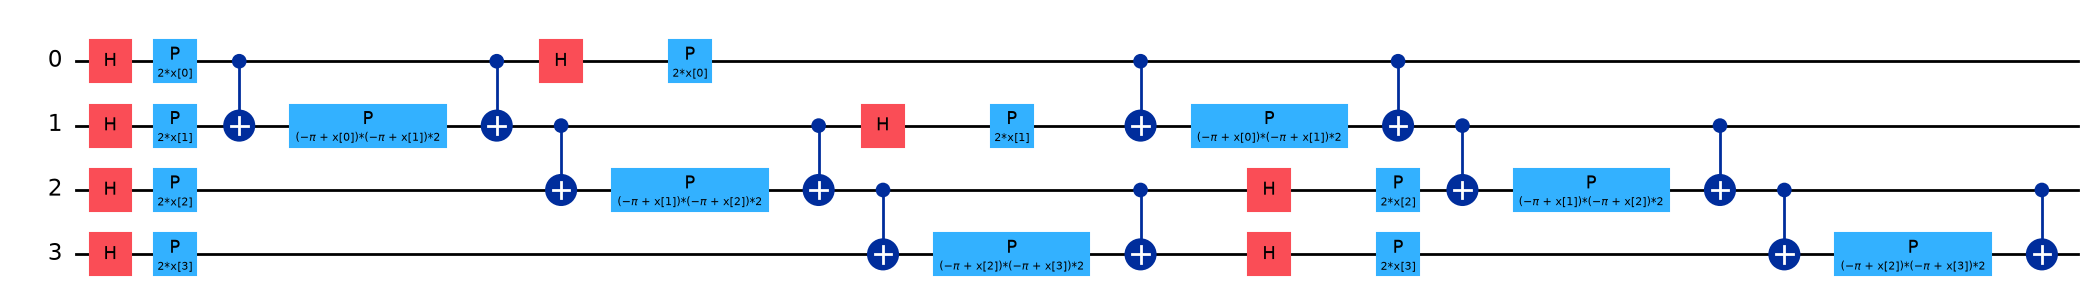

In [11]:
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit_machine_learning.kernels import FidelityQuantumKernel

try:
    # Qiskit >= 1.3: the function form returns a circuit made of standard gates already.
    from qiskit.circuit.library import zz_feature_map
    feature_map = zz_feature_map(feature_dimension=N_FEATURES, reps=2, entanglement="linear")
    print("Using zz_feature_map() (function form).")
except ImportError:
    # Older Qiskit: the class form must be decomposed or Aer cannot execute it.
    from qiskit.circuit.library import ZZFeatureMap
    feature_map = ZZFeatureMap(feature_dimension=N_FEATURES, reps=2, entanglement="linear").decompose()
    print("Using ZZFeatureMap class (legacy form) + .decompose().")

print(f"Qubits: {feature_map.num_qubits} | depth: {feature_map.depth()} | ops: {dict(feature_map.count_ops())}")

try:
    # Nicer rendering; needs pylatexenc (it is in requirements.txt).
    _fig = feature_map.draw("mpl", fold=40)
    display(_fig)
    plt.close(_fig)   # close it so the inline backend does not also re-emit the figure
except Exception as e:
    print(f"(matplotlib circuit drawing unavailable: {type(e).__name__}; using text drawer)\n")
    print(feature_map.draw("text", fold=110))

In [12]:
fidelity_local = ComputeUncompute(sampler=LOCAL_SAMPLER)
quantum_kernel_sim = FidelityQuantumKernel(feature_map=feature_map, fidelity=fidelity_local)

n_pairs = N_TRAIN * (N_TRAIN - 1) // 2 + N_TEST * N_TRAIN
print(f"About to evaluate ~{n_pairs} fidelity circuits on device '{LOCAL_DEVICE}'. "
      f"This is the slowest cell in the notebook.")

t0 = time.time()
K_train_qsim = quantum_kernel_sim.evaluate(x_vec=X_train)
K_test_qsim = quantum_kernel_sim.evaluate(x_vec=X_test, y_vec=X_train)
t1 = time.time()
print(f"Local {LOCAL_DEVICE} simulation: computed {N_TRAIN}x{N_TRAIN} + {N_TEST}x{N_TRAIN} "
      f"quantum kernel matrices in {t1 - t0:.1f}s")

About to evaluate ~4515 fidelity circuits on device 'CPU'. This is the slowest cell in the notebook.
Local CPU simulation: computed 70x70 + 30x70 quantum kernel matrices in 116.3s


In [17]:
C_qsim = 1.0  # kept fixed (no grid search) -- this is a fair-comparison choice, documented here,
              # not tuned against the test set. Feel free to grid-search C only (kernel is fixed) if desired.

acc_qsim, _ = fit_eval_precomputed(K_train_qsim, y_train, K_test_qsim, y_test, C=C_qsim)
cv_mean_qsim, cv_std_qsim = cv_precomputed(K_train_qsim, y_train, n_splits=5, C=C_qsim)
align_qsim = kernel_target_alignment(K_train_qsim, y_train_pm)

print(f"Quantum (sim) -> test acc: {acc_qsim:.4f} | CV: {cv_mean_qsim:.4f} +/- {cv_std_qsim:.4f} | alignment: {align_qsim:.4f}")

results.append(dict(method="Quantum (local sim)", n_train=len(y_train), test_acc=acc_qsim,
                    cv_mean=cv_mean_qsim, cv_std=cv_std_qsim, alignment=align_qsim))
kernel_matrices["Quantum (local sim)"] = (K_train_qsim, y_train)

Quantum (sim) -> test acc: 0.7333 | CV: 0.8286 +/- 0.1069 | alignment: 0.1501


### 4.1 Heatmaps so far (3 of 4 kernels)

Samples are sorted by class label, so a kernel that separates the classes well should show
a visible 2×2 block structure.

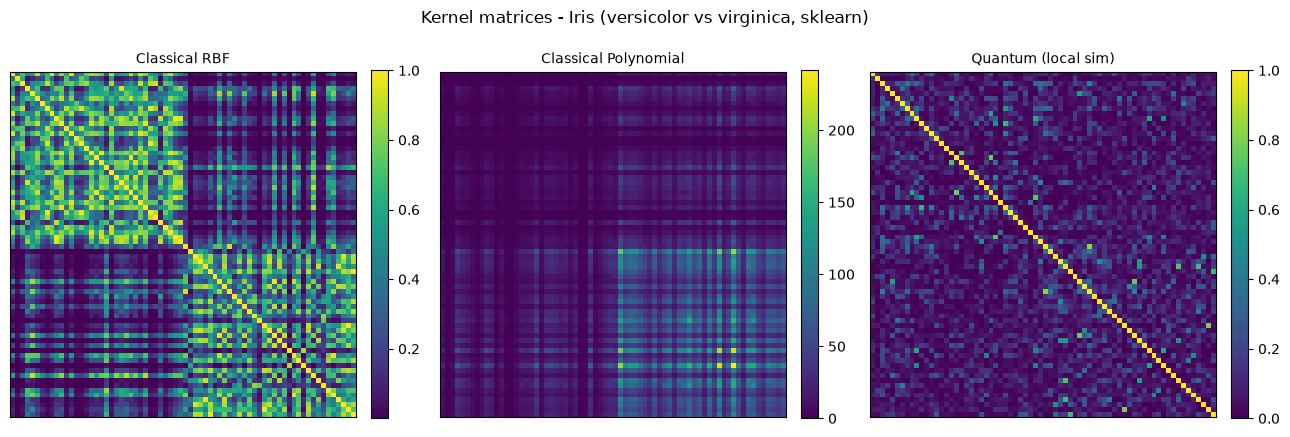

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, name in zip(axes, ["Classical RBF", "Classical Polynomial", "Quantum (local sim)"]):
    K, y_ = kernel_matrices[name]
    plot_kernel_heatmap(K, y_, name, ax=ax)
plt.suptitle(f"Kernel matrices - {DATASET_LABEL}", y=1.02)
plt.tight_layout()
plt.show()

## 5. Results Summary & Conclusion 🟢

The table below is the primary comparison of the three kernels. All rows use the same
dataset, preprocessing, train/test split, and evaluation metrics.

In [19]:
if "results" not in globals() or not results:
    print("Run Sections 1–4 first so the kernel results are populated before viewing the summary table.")
else:
    summary_df = pd.DataFrame(results)
    summary_df.insert(0, "dataset", DATASET_LABEL)
    summary_df = summary_df[["dataset", "method", "n_train", "test_acc", "cv_mean", "cv_std", "alignment"]]
    summary_df.columns = ["Dataset", "Method", "N (train)", "Test Accuracy",
                          "CV Mean Acc.", "CV Std Acc.", "Kernel-Target Alignment"]
    summary_df = summary_df.round(4)

    display(summary_df)


,Dataset,Method,N (train),Test Accuracy,CV Mean Acc.,CV Std Acc.,Kernel-Target Alignment
0,"Iris (versicolor vs virginica, sklearn)",Classical RBF,70,0.8667,0.9714,0.0350,0.3674
1,"Iris (versicolor vs virginica, sklearn)",Classical Polynomial,70,0.8667,0.9429,0.0286,0.2191
2,"Iris (versicolor vs virginica, sklearn)",Quantum (local sim),70,0.7333,0.8286,0.1069,0.1501


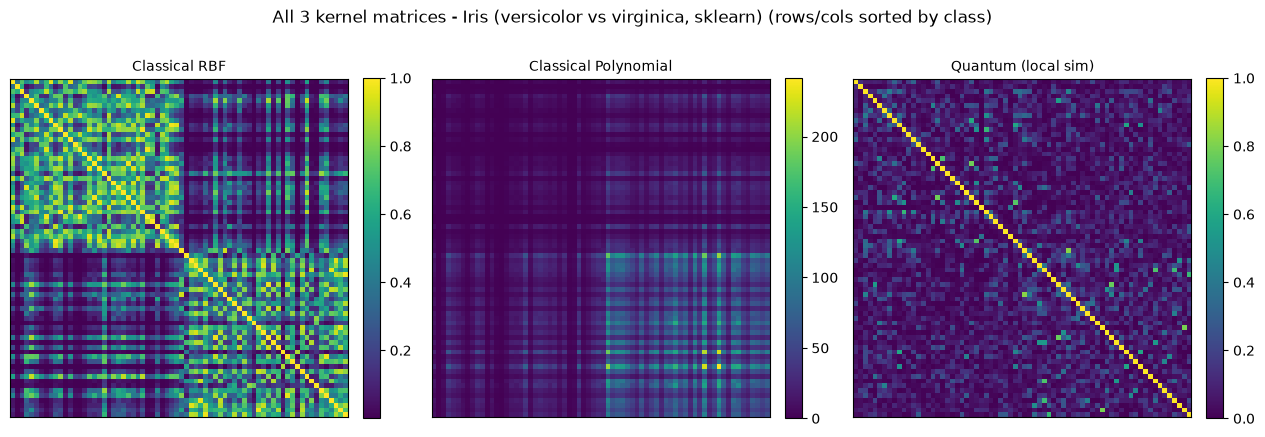

In [20]:
names = [n for n in ["Classical RBF", "Classical Polynomial",
                     "Quantum (local sim)"]
         if n in kernel_matrices]

fig, axes = plt.subplots(1, len(names), figsize=(4.25 * len(names), 4.2))
axes = np.atleast_1d(axes)
for ax, name in zip(axes, names):
    K, y_ = kernel_matrices[name]
    plot_kernel_heatmap(K, y_, name, ax=ax)
plt.suptitle(f"All {len(names)} kernel matrices - {DATASET_LABEL} (rows/cols sorted by class)", y=1.03)
plt.tight_layout()
plt.show()

### Conclusion

The cell below **programmatically derives its conclusion from the numbers actually
produced above** — it does not assume an outcome in either direction. This is intentional:
the goal of this notebook is to report whatever the data show, including a **null result**
(no quantum advantage), which is itself a valid and reportable finding for this
dataset/feature-map combination and must not be suppressed.

In [21]:
if "results" not in globals() or not results:
    print("Run Sections 1–4 before the conclusion cell so the results dictionary exists.")
else:
    classical_best = max(
        (r for r in results if r["method"].startswith("Classical")),
        key=lambda r: r["cv_mean"],
    )
    quantum_rows = [r for r in results if r["method"] == "Quantum (local sim)"]

    print("=" * 78)
    print("AUTOMATED SUMMARY")
    print(f"Dataset: {DATASET_LABEL}")
    print("=" * 78)
    print(f"Best classical baseline : {classical_best['method']} "
          f"(CV mean acc. {classical_best['cv_mean']:.4f} +/- {classical_best['cv_std']:.4f}, "
          f"alignment {classical_best['alignment']:.4f})")

    for qr in quantum_rows:
        delta_acc = qr["cv_mean"] - classical_best["cv_mean"]
        delta_align = qr["alignment"] - classical_best["alignment"]
        combined_std = np.sqrt(qr["cv_std"] ** 2 + classical_best["cv_std"] ** 2)
        advantage = (delta_acc > combined_std) and (delta_align > 0)
        print(f"\n--- {qr['method']} vs. best classical ({classical_best['method']}) ---")
        print(f"  CV accuracy:  {qr['cv_mean']:.4f}  (delta = {delta_acc:+.4f}, "
              f"combined std = {combined_std:.4f})")
        print(f"  Alignment:    {qr['alignment']:.4f}  (delta = {delta_align:+.4f})")
        if advantage:
            print(f"  VERDICT: {qr['method']} shows a MEASURABLE ADVANTAGE over the classical "
                  f"baseline by the pre-specified bar above.")
        else:
            print(f"  VERDICT: {qr['method']} does NOT show a measurable advantage over the "
                  f"classical baseline on this dataset/feature-map - reported plainly, as a "
                  f"genuine (and common, for this kind of low-dimensional tabular data) null result.")

    print("\n" + "=" * 78)


AUTOMATED SUMMARY
Dataset: Iris (versicolor vs virginica, sklearn)
Best classical baseline : Classical RBF (CV mean acc. 0.9714 +/- 0.0350, alignment 0.3674)

--- Quantum (local sim) vs. best classical (Classical RBF) ---
  CV accuracy:  0.8286  (delta = -0.1429, combined std = 0.1125)
  Alignment:    0.1501  (delta = -0.2174)
  VERDICT: Quantum (local sim) does NOT show a measurable advantage over the classical baseline on this dataset/feature-map - reported plainly, as a genuine (and common, for this kind of low-dimensional tabular data) null result.



**Interpreting the comparison:**

The quantum kernel should be judged against both classical baselines using the same test accuracy,
cross-validation variability, and kernel-target alignment metrics. A higher alignment means the
kernel geometry is more closely related to the class labels, but it does not by itself guarantee
better generalization. The automated verdict above uses both CV accuracy and alignment, and reports
a null result when the quantum kernel does not clear the pre-specified advantage threshold.


**Things worth trying from here (all free, all local):**
- Flip `DATASET` between `"breast_cancer"` and `"iris"` and re-run - iris (versicolor/virginica)
  is the harder, more overlapping problem of the two.
- Raise `N_QUBITS` to 5 or 6 for breast cancer to retain more PCA variance, and watch the
  Section 4 runtime grow.
- Change `reps` or `entanglement` (`"linear"` / `"full"` / `"circular"`) on the feature map.
- Raise `SUBSAMPLE_SIZE` for tighter CV error bars.